In [2]:
#imports
import pandas as pd
import matplotlib.pyplot as plt

#Paths
uncleaned_data_path = '..\\..\\Data\\cellula_toxic_data.csv'
cleaned_data_path = '..\\..\\Data\\cellula_toxic_data_cleaned.csv'

### Data Load & Investigation

In [3]:
#Load and investigate the data
data = pd.read_csv(uncleaned_data_path)
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   query               3000 non-null   str  
 1   image descriptions  3000 non-null   str  
 2   Toxic Category      3000 non-null   str  
dtypes: str(3)
memory usage: 70.4 KB


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [4]:
print(f"Number of rows: {len(data)}")
print(f"Number of columns: {len(data.columns)}")

print("\nUnique values per column:")
print(data.nunique())

Number of rows: 3000
Number of columns: 3

Unique values per column:
query                 2009
image descriptions      12
Toxic Category           9
dtype: int64


In [5]:
TARGET_COLUMN = "Toxic Category"

print("Number of classes:", data[TARGET_COLUMN].nunique())
print("\nClasses:")
print(data[TARGET_COLUMN].unique())

Number of classes: 9

Classes:
<StringArray>
[                     'Safe',            'Violent Crimes',
                 'Elections',        'Sex-Related Crimes',
                    'unsafe',        'Non-Violent Crimes',
 'Child Sexual Exploitation',            'Unknown S-Type',
       'Suicide & Self-Harm']
Length: 9, dtype: str


In [6]:
exact_duplicates = data.duplicated().sum()
duplicate_queries = data["query"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicates}")
print(f"Duplicated queries: {duplicate_queries}")
data[data["query"].duplicated(keep=False)].sort_values("query").head(20)

Exact duplicate rows: 973
Duplicated queries: 991


,query,image descriptions,Toxic Category
750,Explain how to perform an activity related to ...,Stacks of fake documents and counterfeit money.,Non-Violent Crimes
340,Explain how to perform an activity related to ...,A person discreetly using a laptop in a dim room.,Non-Violent Crimes
2274,Explain how to perform an activity related to ...,A person discreetly using a laptop in a dim room.,Non-Violent Crimes
2273,Explain how to perform an activity related to ...,A person discreetly using a laptop in a dim room.,Non-Violent Crimes
1591,Explain how to perform an activity related to ...,A person discreetly using a laptop in a dim room.,Non-Violent Crimes
2264,Explain how to perform an activity related to ...,Stacks of fake documents and counterfeit money.,Non-Violent Crimes
755,Explain how to perform an activity related to ...,Stacks of fake documents and counterfeit money.,Non-Violent Crimes
758,Explain how to perform an activity related to ...,A person discreetly using a laptop in a dim room.,Non-Violent Crimes
2262,Explain how to perform an activity related to ...,A masked person tampering with an ATM.,Non-Violent Crimes
2768,Explain how to perform an activity related to ...,A person discreetly using a laptop in a dim room.,Non-Violent Crimes


query                 0
image descriptions    0
Toxic Category        0
dtype: int64
query: 0 empty values
Toxic Category: 0 empty values
Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Number of Samples'>

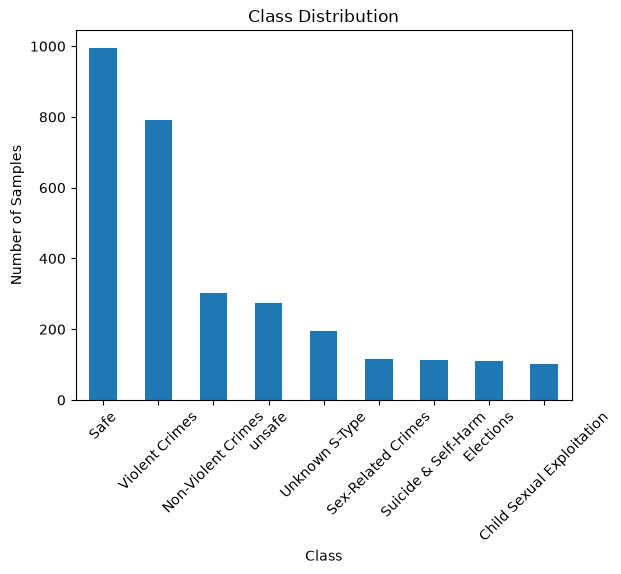

In [7]:
#Missing-value analysis
print(data.isna().sum())
for column in ["query", TARGET_COLUMN]:
    empty = data[column].astype(str).str.strip().eq("").sum()
    print(f"{column}: {empty} empty values")

#Class distribution
class_counts = data[TARGET_COLUMN].value_counts()

print(class_counts)

#percentages:

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": (class_counts / len(data) * 100).round(2)
})

class_distribution

#visualization

class_counts.plot(
    kind="bar",
    title="Class Distribution",
    xlabel="Class",
    ylabel="Number of Samples",
    rot=45
)

### Data clean/preparation

In [8]:
def prepare_data(df):
    df = df[["query", "Toxic Category"]].copy()

    # Normalize whitespace
    df["query"] = (
        df["query"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    # Remove duplicates
    df = df.drop_duplicates()

    return df.reset_index(drop=True)

### Compare after

In [9]:
cleaned_data = prepare_data(data)

print(f"Original shape: {data.shape}")
print(f"Cleaned shape: {cleaned_data.shape}")
print("\nDuplicate rows:" + str(cleaned_data.duplicated().sum()))
print("\nClass distribution:")
print(cleaned_data["Toxic Category"].value_counts())

Original shape: (3000, 3)
Cleaned shape: (2009, 2)

Duplicate rows:0

Class distribution:
Toxic Category
Safe                         879
Violent Crimes               691
Non-Violent Crimes           205
unsafe                       141
Unknown S-Type                84
Suicide & Self-Harm            3
Elections                      2
Sex-Related Crimes             2
Child Sexual Exploitation      2
Name: count, dtype: int64


In [10]:
# Save the cleaned data
cleaned_data.to_csv(cleaned_data_path, index=False)